In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score 

In [2]:
df=pd.read_csv("StudentsPerformance.csv")

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.isnull().any()

gender                         False
race/ethnicity                 False
parental level of education    False
lunch                          False
test preparation course        False
math score                     False
reading score                  False
writing score                  False
dtype: bool

No missing values

**Creating target variable**

In [5]:
df["Score"]=df[['math score','reading score','writing score']].mean(axis=1)

In [6]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race/ethnicity               1000 non-null   object 
 2   parental level of education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test preparation course      1000 non-null   object 
 5   math score                   1000 non-null   int64  
 6   reading score                1000 non-null   int64  
 7   writing score                1000 non-null   int64  
 8   Score                        1000 non-null   float64
dtypes: float64(1), int64(3), object(5)
memory usage: 70.4+ KB


In [8]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'Score'],
      dtype='object')

In [9]:
df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]
df.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


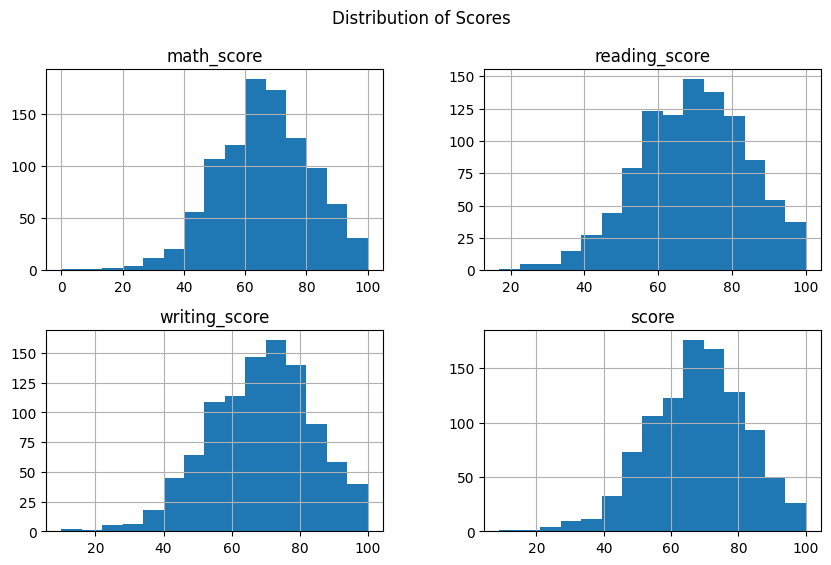

In [10]:
#histogram representation
num_col=['math_score',	'reading_score', 'writing_score', 'score']
df[num_col].hist(figsize=(10,6),bins=15)
plt.suptitle("Distribution of Scores")
plt.show()

In [11]:
df.count(axis=0)

gender                         1000
race/ethnicity                 1000
parental_level_of_education    1000
lunch                          1000
test_preparation_course        1000
math_score                     1000
reading_score                  1000
writing_score                  1000
score                          1000
dtype: int64

C:\Users\Neelabh\AppData\Local\Temp\ipykernel_2372\3618454749.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
C:\Users\Neelabh\AppData\Local\Temp\ipykernel_2372\3618454749.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
C:\Users\Neelabh\AppData\Local\Temp\ipykernel_2372\3618454749.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
C:\Users\Neelabh\AppData\Local\Temp\ipykernel_2372\3618454749.py:6: FutureWarning: 

Passing `

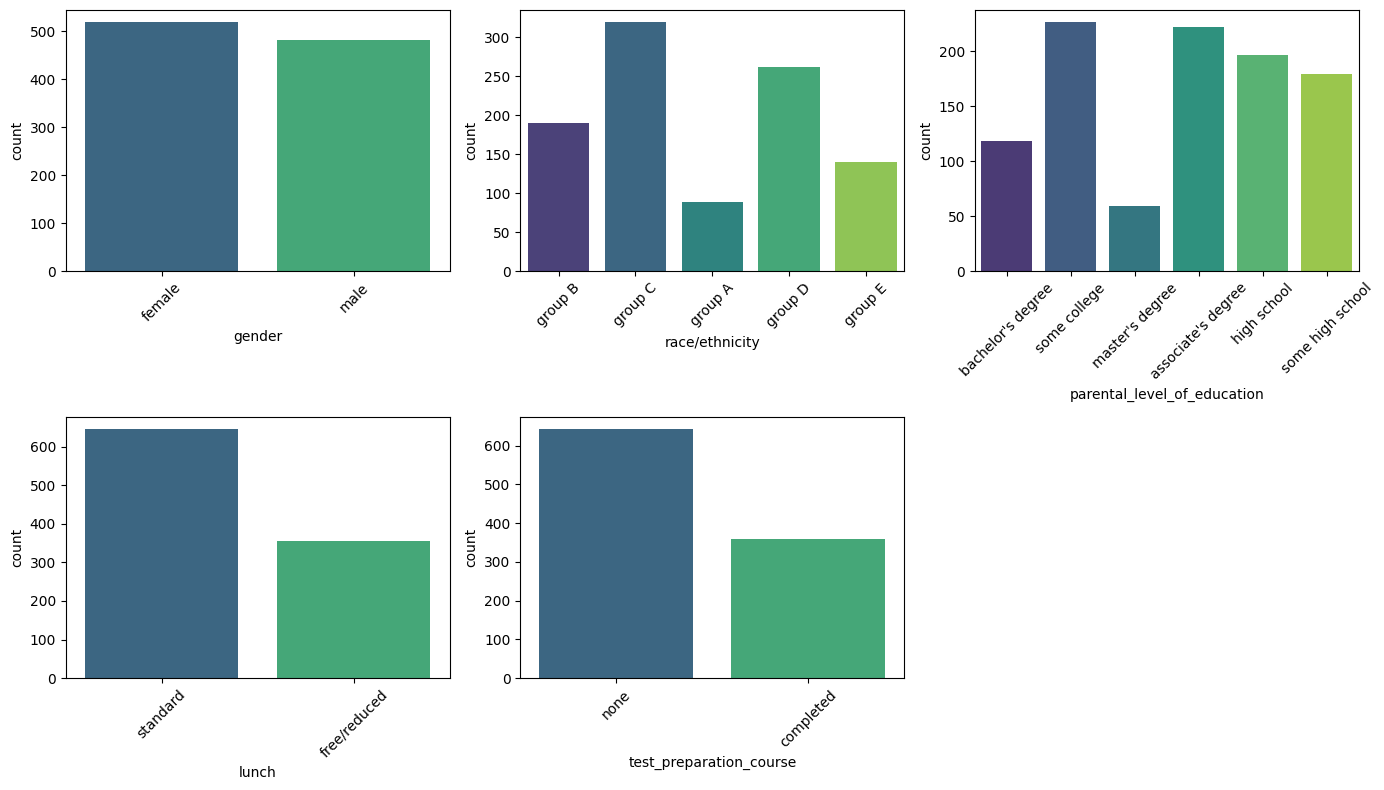

In [12]:
#categorical columns representation
cat_col=['gender','race/ethnicity','parental_level_of_education','lunch','test_preparation_course']
plt.figure(figsize=(14,8))
for i, col in enumerate(cat_col):
    plt.subplot(2, 3, i+1)
    sns.countplot(data=df, x=col, palette='viridis')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

females are slightly more than males
majority of students belongs to class c
Most students have standard lunch, not “free/reduced.”
Many students did not complete the test preparation course.
less parents have masters degree

C:\Users\Neelabh\AppData\Local\Temp\ipykernel_2372\1243061752.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y='score', palette='coolwarm')


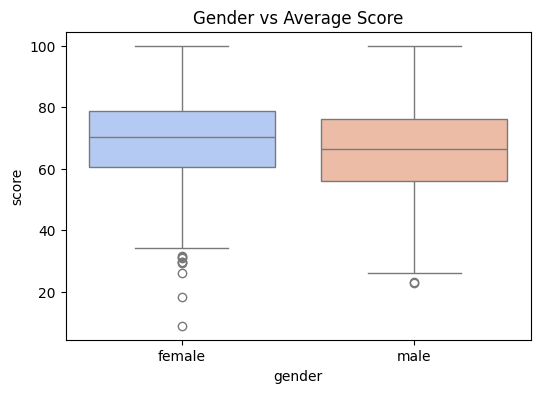

In [13]:
#bivariate analysis
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='gender', y='score', palette='coolwarm')
plt.title("Gender vs Average Score")
plt.show()

C:\Users\Neelabh\AppData\Local\Temp\ipykernel_2372\1082879910.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='parental_level_of_education', y='score', palette='mako')


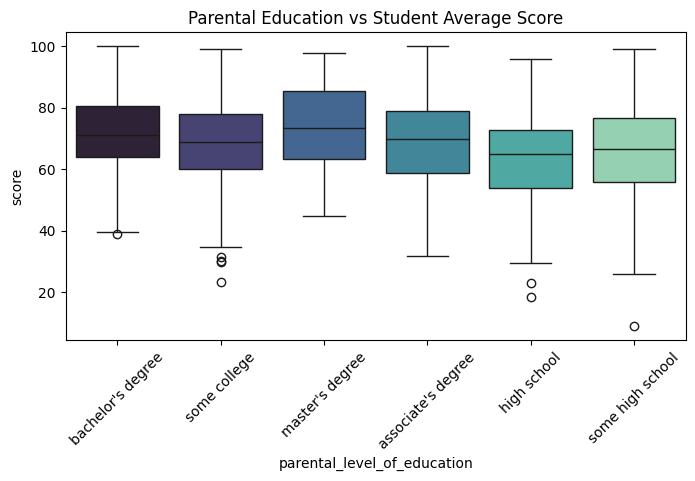

In [14]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='parental_level_of_education', y='score', palette='mako')
plt.xticks(rotation=45)
plt.title("Parental Education vs Student Average Score")
plt.show()

parents education affects students performance

C:\Users\Neelabh\AppData\Local\Temp\ipykernel_2372\610469919.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='test_preparation_course', y='score', palette='crest')


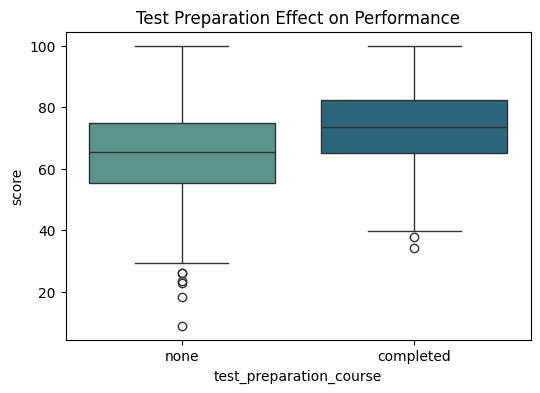

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='test_preparation_course', y='score', palette='crest')
plt.title("Test Preparation Effect on Performance")
plt.show()

test preparation slightly improves the performance

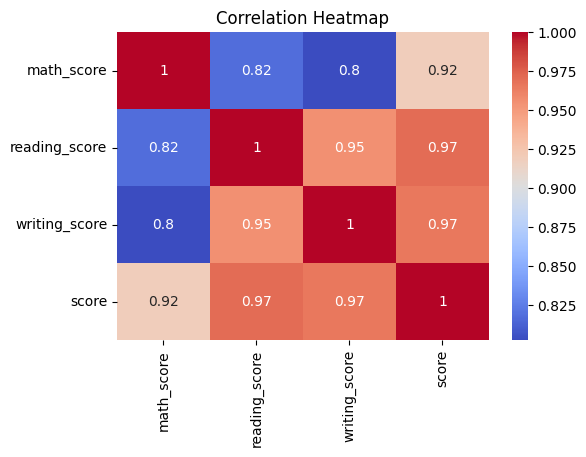

In [16]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['math_score','reading_score','writing_score','score']].corr(), 
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

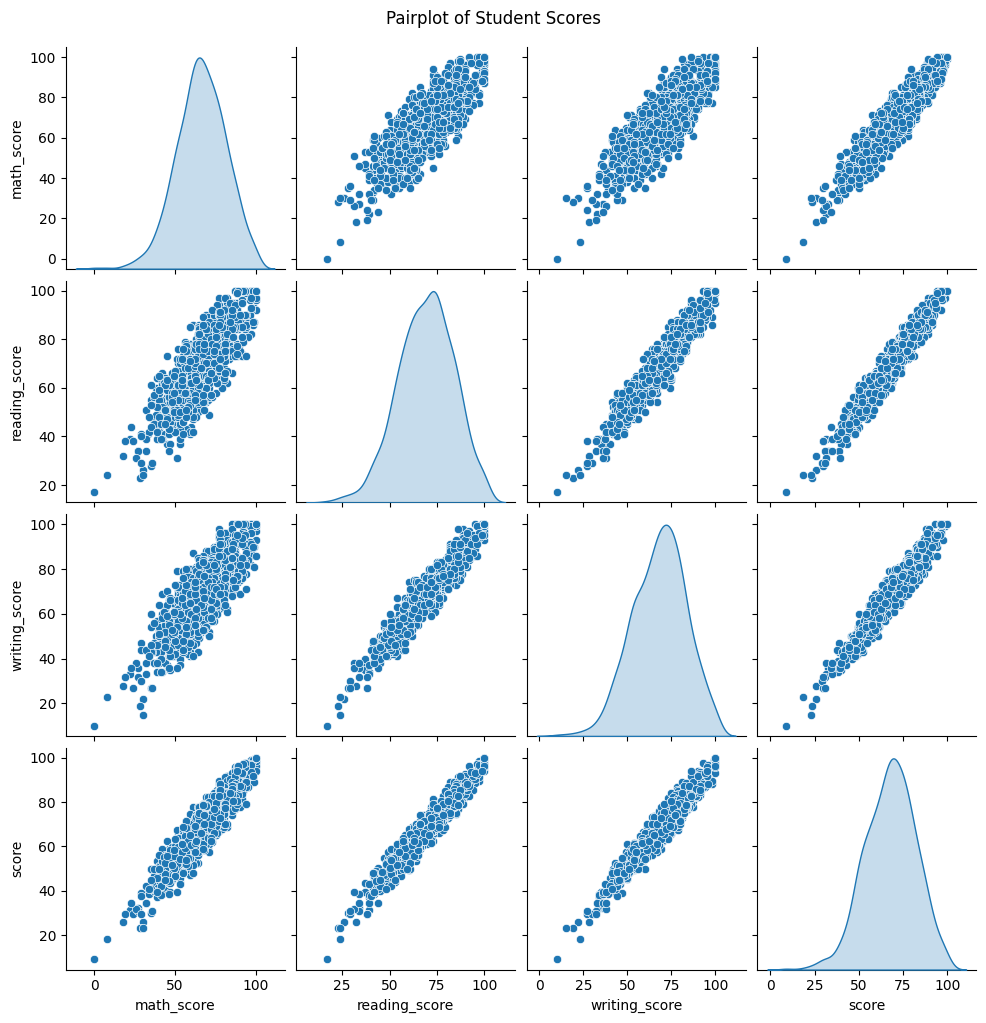

In [17]:
sns.pairplot(df[['math_score', 'reading_score', 'writing_score', 'score']], diag_kind='kde')
plt.suptitle("Pairplot of Student Scores", y=1.02)
plt.show()

strong linear relationship

**encoding**

In [18]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in cat_col:
    df[i]=le.fit_transform(df[i])


In [19]:
df.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,score
0,0,1,1,1,1,72,72,74,72.666667
1,0,2,4,1,0,69,90,88,82.333333
2,0,1,3,1,1,90,95,93,92.666667
3,1,0,0,0,1,47,57,44,49.333333
4,1,2,4,1,1,76,78,75,76.333333


In [20]:
df["parental_level_of_education"].unique()

array([1, 4, 3, 0, 2, 5])

**train test split**

In [44]:
x = df.drop(columns=['score', 'math_score', 'reading_score', 'writing_score'])
y=df['score']

In [46]:
x

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course
0,0,1,1,1,1
1,0,2,4,1,0
2,0,1,3,1,1
3,1,0,0,0,1
4,1,2,4,1,1
...,...,...,...,...,...
995,0,4,3,1,0
996,1,2,2,0,1
997,0,2,2,0,0
998,0,3,4,1,0


In [47]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [48]:
print("Training set shape:", x_train.shape)
print("Testing set shape:", x_test.shape)

Training set shape: (800, 5)
Testing set shape: (200, 5)


In [49]:
#applying linear regression
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [50]:
model.intercept_

np.float64(66.6539204635644)

**model evaluation**

In [52]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score:", round(r2, 3))
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))

R² Score: 0.126
MAE: 10.717
RMSE: 13.691


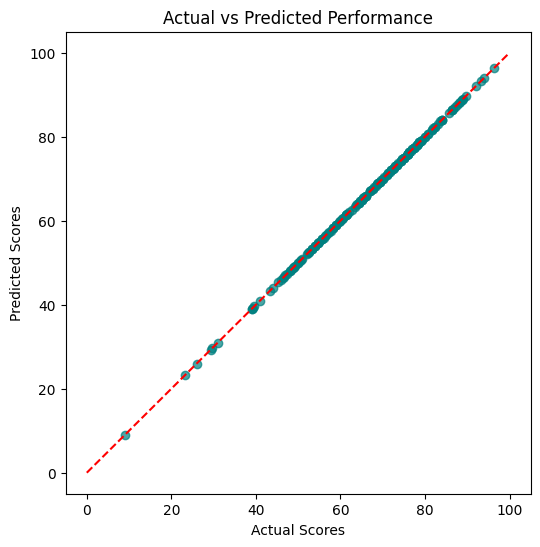

In [39]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Performance")
plt.plot([0,100],[0,100],'r--')
plt.show()

In [53]:
coeff = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coeff)

                       Feature  Coefficient
3                        lunch     9.095382
1               race/ethnicity     1.913564
2  parental_level_of_education    -0.524150
0                       gender    -4.173763
4      test_preparation_course    -8.189341


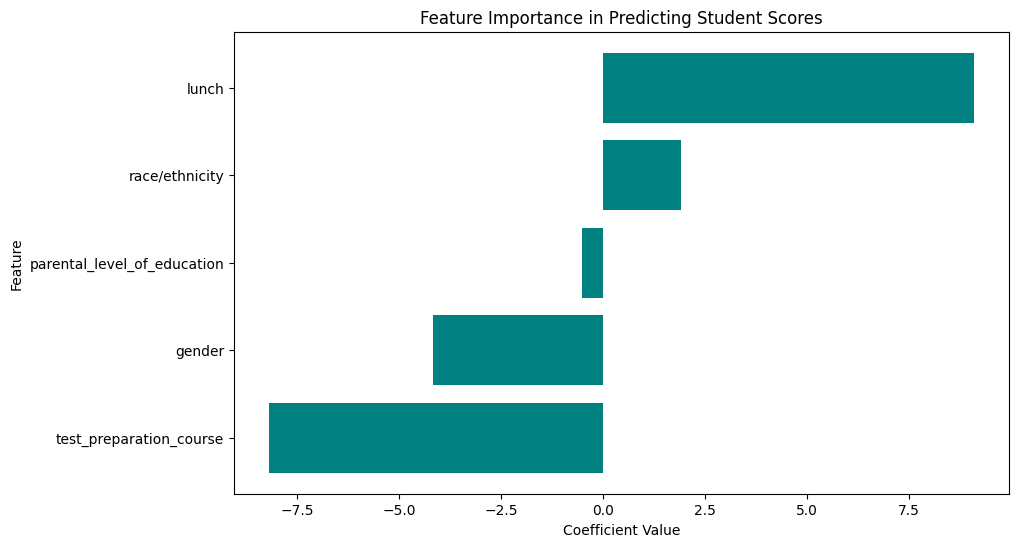

,Feature,Coefficient
3,lunch,9.095382
1,race/ethnicity,1.913564
2,parental_level_of_education,-0.524150
0,gender,-4.173763
4,test_preparation_course,-8.189341


In [55]:
coeff = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(coeff['Feature'], coeff['Coefficient'], color='teal')
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Importance in Predicting Student Scores")
plt.gca().invert_yaxis()
plt.show()

coeff

In [58]:
import pickle

# Save model
with open('student_performance_model.pkl', 'wb') as file:
    pickle.dump(model, file)

# Save the columns (very important)
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(x.columns.tolist(), f)